Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


Load Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


Visualize Sample Images

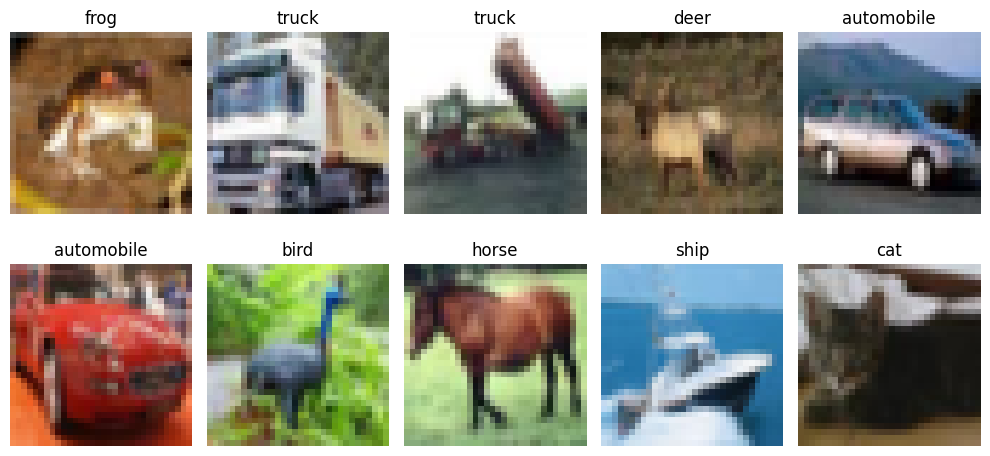

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

Preprocessing
We normalize pixel values from 0–255 → 0–1 so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

 Part 1: ANN Model
ANN treats images as flat vectors, so it cannot preserve spatial features.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\spars\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.2695 - loss: 1.9997 - val_accuracy: 0.3472 - val_loss: 1.8368
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3134 - loss: 1.8700 - val_accuracy: 0.3554 - val_loss: 1.7903
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3325 - loss: 1.8282 - val_accuracy: 0.3790 - val_loss: 1.7608
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3439 - loss: 1.7893 - val_accuracy: 0.3810 - val_loss: 1.7292
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3546 - loss: 1.7676 - val_accuracy: 0.3932 - val_loss: 1.6954
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3665 - loss: 1.7431 - val_accuracy: 0.4062 - val_loss: 1.6993
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.3712 - loss: 1.7289 - val_accuracy: 0.3810 - val_loss: 1.7234
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3729 - loss: 1.7162 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4281 - loss: 1.6352
ANN Test Accuracy: 0.42809998989105225


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\spars\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 103ms/step - accuracy: 0.4620 - loss: 1.5024 - val_accuracy: 0.5400 - val_loss: 1.2998
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.6075 - loss: 1.1257 - val_accuracy: 0.5946 - val_loss: 1.1298
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.6678 - loss: 0.9536 - val_accuracy: 0.5744 - val_loss: 1.2167
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 88ms/step - accuracy: 0.7105 - loss: 0.8251 - val_accuracy: 0.6888 - val_loss: 0.8994
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 94ms/step - accuracy: 0.7406 - loss: 0.7418 - val_accuracy: 0.6944 - val_loss: 0.8611
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 96ms/step - accuracy: 0.7653 - loss: 0.6641 - val_accuracy: 0.5708 - val_loss: 1.4764
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accuracy: 0.7885 - loss: 0.5971 - val_accuracy: 0.7208 - val_loss: 0.8504
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 70s 100ms/step - accuracy: 0.8091 - loss: 0.5391

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7190 - loss: 0.9228
CNN Test Accuracy: 0.718999981880188


 Compare Learning Curves

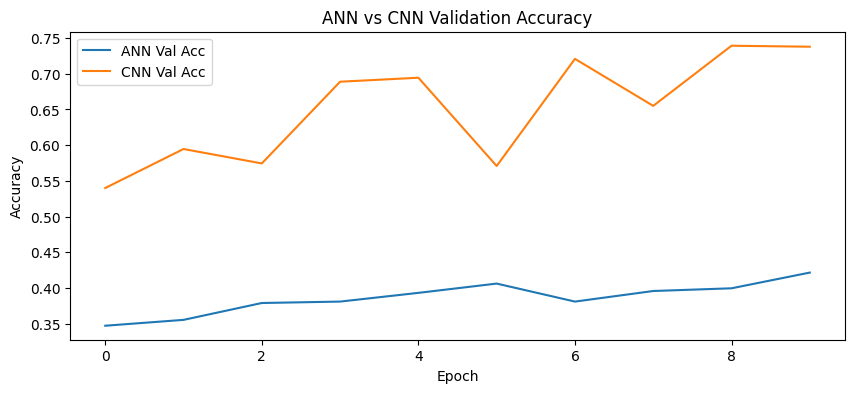

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

- The **CNN model consistently outperformed the ANN model** across all training epochs.
- **CNN validation accuracy** improved from approximately **54% to 74%**, showing a significant learning trend.
- **ANN validation accuracy** increased gradually from **35% to 42%**, but remained much lower than CNN.
- CNN experienced minor fluctuations (around epochs **5** and **7**), yet quickly recovered and achieved its highest validation accuracy.
- ANN showed a relatively stable learning curve with only small improvements, indicating limited capability to capture image features.
- The final validation accuracy of CNN (**~74%**) is about **32 percentage points higher** than ANN (**~42%**).
- The results demonstrate that **Convolutional Neural Networks (CNNs)** are more effective than **Artificial Neural Networks (ANNs)** for image classification tasks because CNNs automatically learn spatial features through convolution and pooling layers.
- Overall, the graph confirms that **CNN provides better generalization and higher validation performance** compared to ANN on the same dataset.


 
 
 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [12]:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 45ms/step - accuracy: 0.3830 - loss: 1.6888 - val_accuracy: 0.5066 - val_loss: 1.3710
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.4816 - loss: 1.4509 - val_accuracy: 0.5214 - val_loss: 1.3200
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 62s 44ms/step - accuracy: 0.5142 - loss: 1.3652 - val_accuracy: 0.5816 - val_loss: 1.1783
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - accuracy: 0.5402 - loss: 1.2965 - val_accuracy: 0.5996 - val_loss: 1.1251
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 52ms/step - accuracy: 0.5530 - loss: 1.2639 - val_accuracy: 0.6220 - val_loss: 1.0489
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.5671 - loss: 1.2323 - val_accuracy: 0.6444 - val_loss: 1.0128
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 46ms/step - accuracy: 0.5772 - loss: 1.2021 - val_accuracy: 0.6218 - val_loss: 1.0787
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.5869 -

In [13]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Augmented CNN Test Loss:", aug_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6221 - loss: 1.1049
Augmented CNN Test Accuracy: 0.6220999956130981
Augmented CNN Test Loss: 1.1049153804779053


Final Comparison Table

In [14]:
results = pd.DataFrame({
    "Model": ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss": [ann_test_loss, cnn_test_loss, aug_test_loss]
})

print(results)

           Model  Test Accuracy  Test Loss
0            ANN         0.4281   1.635182
1            CNN         0.7190   0.922825
2  Augmented CNN         0.6221   1.104915


- The **CNN model** achieved the highest test accuracy of **71.90%** with the lowest test loss (**0.9228**), making it the best-performing model.
- The **ANN model** obtained a test accuracy of **42.81%**, indicating that treating images as flattened vectors is less effective for image classification.
- The **Augmented CNN model** achieved a test accuracy of **62.21%**, outperforming the ANN but performing lower than the basic CNN in this experiment.
- Although data augmentation is generally used to improve model generalization and reduce overfitting, it did not improve the test accuracy in this 20-epoch training setup. Additional hyperparameter tuning or longer training may lead to better results.
- Overall, the results demonstrate that **CNNs are more suitable than ANNs for image classification tasks** because they can automatically learn spatial and hierarchical features from images.

### Conclusion

Among the three models, the **CNN model provided the best overall performance**, achieving the highest accuracy and the lowest loss on the test dataset. The experiment confirms the effectiveness of convolutional neural networks for image classification compared to traditional artificial neural networks.

In ANN model, Increase ANN layers, epoch to 20 and Add EarlyStopping

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping Callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Improved ANN Model
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

# Evaluate the model
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)

print("ANN Test Accuracy:", ann_test_acc)
print("ANN Test Loss:", ann_test_loss)

C:\Users\spars\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - accuracy: 0.2277 - loss: 2.0607 - val_accuracy: 0.2982 - val_loss: 1.8912
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.2833 - loss: 1.9300 - val_accuracy: 0.3366 - val_loss: 1.8427
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3044 - loss: 1.8881 - val_accuracy: 0.3546 - val_loss: 1.8305
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 63ms/step - accuracy: 0.3175 - loss: 1.8535 - val_accuracy: 0.3734 - val_loss: 1.7845
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3283 - loss: 1.8326 - val_accuracy: 0.3670 - val_loss: 1.7977
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 64ms/step - accuracy: 0.3355 - loss: 1.8138 - val_accuracy: 0.3778 - val_loss: 1.7687
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 63ms/step - accuracy: 0.3435 - loss: 1.7969 - val_accuracy: 0.3860 - val_loss: 1.7568
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 67ms/step - accuracy: 0.3510 - loss: 1.7812 - 

In [28]:
### Results

| Model | Test Accuracy | Test Loss |
|-------|--------------:|----------:|
| Original ANN | 42.81% | 1.6352 |
| Improved ANN | 40.45% | 1.6624 |

### Observations

- The improved ANN achieved a **test accuracy of 40.45%**, which is **slightly lower** than the original ANN's **42.81%**.
- The **test loss increased** from **1.6352** to **1.6624**, indicating no improvement in the model's overall performance.
- Increasing the number of hidden layers did **not improve** the classification accuracy for this dataset.
- The additional layers increased the model complexity, but the ANN still could not effectively capture the spatial information present in images.
- Although the model was trained for **20 epochs** with **EarlyStopping**, the extra training did not lead to better generalization on the test dataset.
- These results suggest that simply increasing the depth of an ANN is **not sufficient** for image classification tasks such as CIFAR-10.

### Conclusion

The original ANN performed slightly better than the improved ANN. This demonstrates that, for image classification problems, increasing the number of fully connected layers does not necessarily improve performance. Convolutional Neural Networks (CNNs), which are specifically designed to learn spatial features, remain a more suitable choice for this task.

SyntaxError: unterminated string literal (detected at line 10) (3355343541.py, line 10)

In CNN model, Increase epoch to 20, Add EarlyStopping and Add Data Augmentation

In [17]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
# Augmented CNN Model
aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])
# Compile
aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Train
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)
# Evaluate
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)

print("Augmented CNN Test Accuracy:", aug_test_acc)
print("Augmented CNN Test Loss:", aug_test_loss)

C:\Users\spars\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 118ms/step - accuracy: 0.4134 - loss: 1.7185 - val_accuracy: 0.5238 - val_loss: 1.3597
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.5163 - loss: 1.3583 - val_accuracy: 0.5950 - val_loss: 1.1781
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 110ms/step - accuracy: 0.5651 - loss: 1.2301 - val_accuracy: 0.5712 - val_loss: 1.2495
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.5926 - loss: 1.1553 - val_accuracy: 0.5998 - val_loss: 1.2203
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 108ms/step - accuracy: 0.6170 - loss: 1.0984 - val_accuracy: 0.5826 - val_loss: 1.2620
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5745 - loss: 1.2069
Augmented CNN Test Accuracy: 0.5745000243186951
Augmented CNN Test Loss: 1.2069478034973145


In [18]:
# comparison table
updated_results = pd.DataFrame({
    "Model": [
        "Improved ANN",
        "Improved Augmented CNN"
    ],
    "Test Accuracy": [
        ann_test_acc,
        aug_test_acc
    ],
    "Test Loss": [
        ann_test_loss,
        aug_test_loss
    ]
})

updated_results

,Model,Test Accuracy,Test Loss
0,Improved ANN,0.4045,1.662403
1,Improved Augmented CNN,0.5745,1.206948


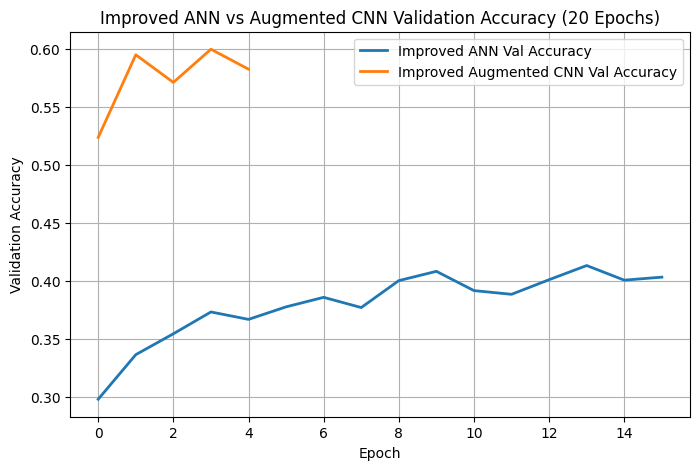

In [23]:
#Validation Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(ann_history.history['val_accuracy'],
         label='Improved ANN Val Accuracy',
         linewidth=2)

plt.plot(aug_history.history['val_accuracy'],
         label='Improved Augmented CNN Val Accuracy',
         linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Improved ANN vs Augmented CNN Validation Accuracy (20 Epochs)")
plt.legend()
plt.grid(True)
plt.show()

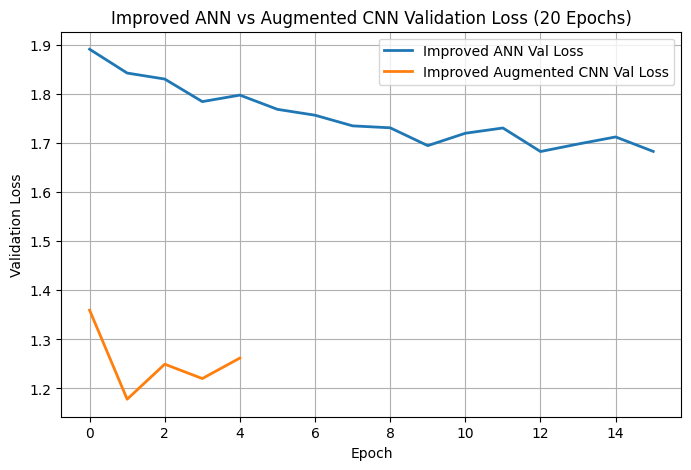

In [24]:
#Validation loss Graph
plt.figure(figsize=(8,5))

plt.plot(ann_history.history['val_loss'],
         label='Improved ANN Val Loss',
         linewidth=2)

plt.plot(aug_history.history['val_loss'],
         label='Improved Augmented CNN Val Loss',
         linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Improved ANN vs Augmented CNN Validation Loss (20 Epochs)")
plt.legend()
plt.grid(True)
plt.show()

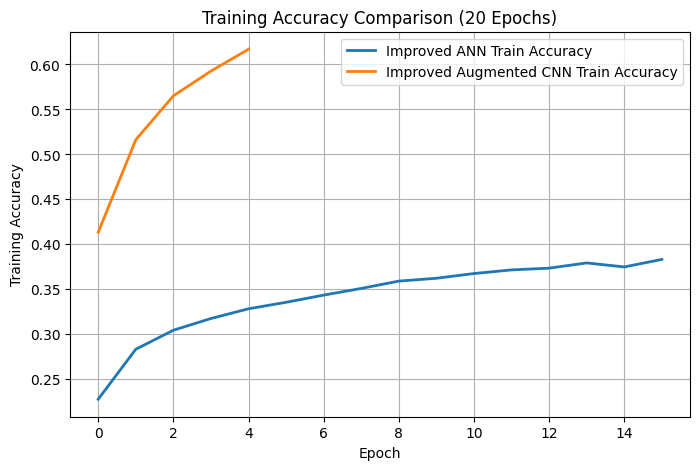

In [25]:
#Training Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(ann_history.history['accuracy'],
         label='Improved ANN Train Accuracy',
         linewidth=2)

plt.plot(aug_history.history['accuracy'],
         label='Improved Augmented CNN Train Accuracy',
         linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison (20 Epochs)")
plt.legend()
plt.grid(True)
plt.show()

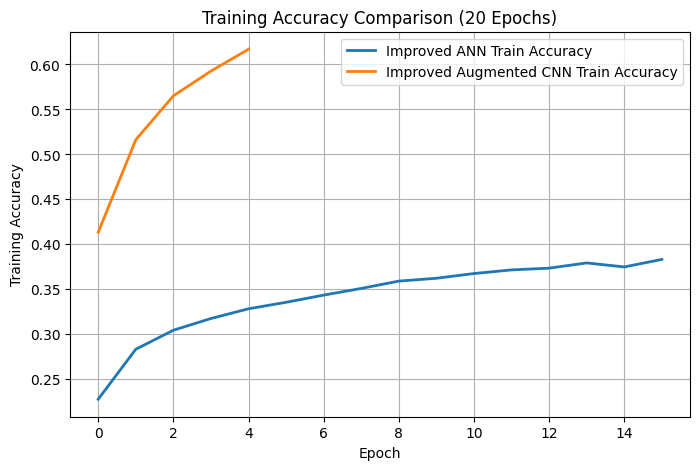

In [27]:
#Training Loss Graph
plt.figure(figsize=(8,5))

plt.plot(ann_history.history['accuracy'],
         label='Improved ANN Train Accuracy',
         linewidth=2)

plt.plot(aug_history.history['accuracy'],
         label='Improved Augmented CNN Train Accuracy',
         linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison (20 Epochs)")
plt.legend()
plt.grid(True)
plt.show()

 The **Augmented CNN** consistently achieved higher **training and validation accuracy** than the Improved ANN throughout training.
- The **Improved ANN** showed a gradual increase in both training and validation accuracy, but its overall performance remained significantly lower than that of the Augmented CNN.
- The **validation loss** of the Augmented CNN remained substantially lower than the ANN validation loss, indicating better learning and generalization.
- The ANN exhibited a slow decrease in validation loss, suggesting that increasing the number of dense layers alone was not sufficient to significantly improve image classification performance.
- The Augmented CNN learned meaningful image features much faster, reaching higher accuracy within the first few epochs.
- The use of **data augmentation** and **convolutional layers** enabled the CNN to learn more robust and spatially relevant features from the images.
- **EarlyStopping** terminated the Augmented CNN training before completing all 20 epochs because the validation performance stopped improving. This helped prevent unnecessary training and reduced the risk of overfitting.
- Overall, the learning curves demonstrate that the **Augmented CNN provides better convergence, lower validation loss, and higher classification accuracy** compared to the Improved ANN.

### Conclusion

The experimental results confirm that **Convolutional Neural Networks (CNNs)** are more effective than **Artificial Neural Networks (ANNs)** for image classification tasks. While increasing the ANN depth and training duration provided only limited improvement, the combination of convolutional layers, data augmentation, and EarlyStopping enabled the Augmented CNN to achieve better learning efficiency and superior overall performance.